In [1]:
# --- Imports ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import Sequence


In [2]:
class HybridDataGenerator(Sequence):
    def __init__(self, image_paths, labels, features, batch_size=16, image_size=(224, 224), shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.features = features
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_features = self.features[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = [img_to_array(load_img(path, target_size=self.image_size)) / 255.0 for path in batch_paths]
        return [np.array(batch_images), np.array(batch_features)], np.array(batch_labels)

    def on_epoch_end(self):
        if self.shuffle:
            zipped = list(zip(self.image_paths, self.labels, self.features))
            np.random.shuffle(zipped)
            self.image_paths, self.labels, self.features = zip(*zipped)


In [3]:
DATASET_DIR = "data"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20
NUM_FEATURES = 10  # Change if you have actual biomarker features

# Load image paths and labels
real_images = sorted(glob(os.path.join(DATASET_DIR, "train", "real", "*.jpg")))
fake_images = sorted(glob(os.path.join(DATASET_DIR, "train", "fake", "*.jpg")))
all_images = real_images + fake_images
labels = [0]*len(real_images) + [1]*len(fake_images)

# Simulated biomarker features (replace with real features)
features = np.random.rand(len(all_images), NUM_FEATURES)

# Train-validation split
train_img, val_img, train_lbl, val_lbl, train_feat, val_feat = train_test_split(
    all_images, labels, features, test_size=0.2, random_state=42
)

# Test data
test_real = sorted(glob(os.path.join(DATASET_DIR, "test", "real", "*.jpg")))
test_fake = sorted(glob(os.path.join(DATASET_DIR, "test", "fake", "*.jpg")))
test_img = test_real + test_fake
test_lbl = [0]*len(test_real) + [1]*len(test_fake)
test_feat = np.random.rand(len(test_img), NUM_FEATURES)  # Replace with real features

# Generators
train_gen = HybridDataGenerator(train_img, train_lbl, train_feat, BATCH_SIZE, IMAGE_SIZE)
val_gen = HybridDataGenerator(val_img, val_lbl, val_feat, BATCH_SIZE, IMAGE_SIZE)
test_gen = HybridDataGenerator(test_img, test_lbl, test_feat, BATCH_SIZE, IMAGE_SIZE, shuffle=False)


In [4]:
def build_ssl_resnet_hybrid(image_shape, num_features):
    image_input = Input(shape=image_shape, name='image_input')
    feature_input = Input(shape=(num_features,), name='feature_input')

    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    merged = Concatenate()([x, feature_input])
    x = Dense(256, activation='relu')(merged)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[image_input, feature_input], outputs=output)
    return model

model = build_ssl_resnet_hybrid((*IMAGE_SIZE, 3), NUM_FEATURES)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


94765736/94765736 [==============================] - 8s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                             

Epoch 1/20
5000/5000 [==============================] - 85s 16ms/step - loss: 0.5787 - accuracy: 0.6990 - val_loss: 0.5135 - val_accuracy: 0.7571
Epoch 2/20
5000/5000 [==============================] - 75s 15ms/step - loss: 0.5280 - accuracy: 0.7444 - val_loss: 0.4949 - val_accuracy: 0.7718
Epoch 3/20
5000/5000 [==============================] - 74s 15ms/step - loss: 0.5025 - accuracy: 0.7639 - val_loss: 0.4731 - val_accuracy: 0.7972
Epoch 4/20
5000/5000 [==============================] - 75s 15ms/step - loss: 0.4914 - accuracy: 0.7725 - val_loss: 0.4508 - val_accuracy: 0.8008
Epoch 5/20
5000/5000 [==============================] - 75s 15ms/step - loss: 0.4805 - accuracy: 0.7816 - val_loss: 0.4376 - val_accuracy: 0.8141
Epoch 6/20
5000/5000 [==============================] - 103s 21ms/step - loss: 0.4800 - accuracy: 0.7808 - val_loss: 0.4443 - val_accuracy: 0.8107
Epoch 7/20
5000/5000 [==============================] - 238s 48ms/step - loss: 0.4690 - accuracy: 0.7866 - val_loss: 0.4474

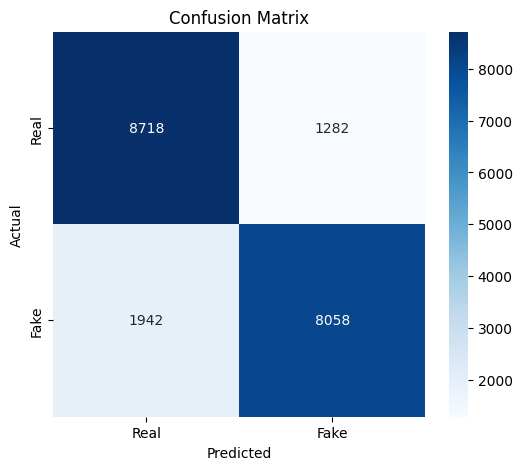

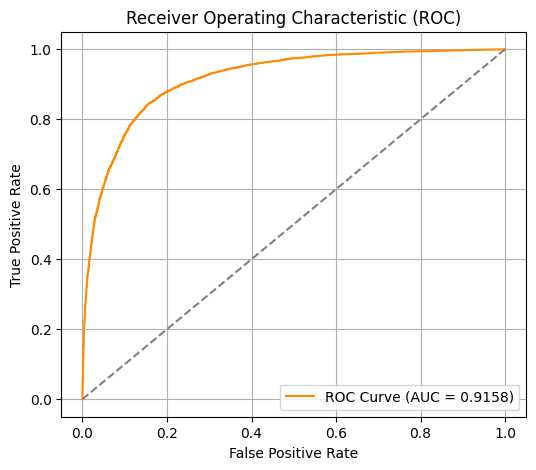

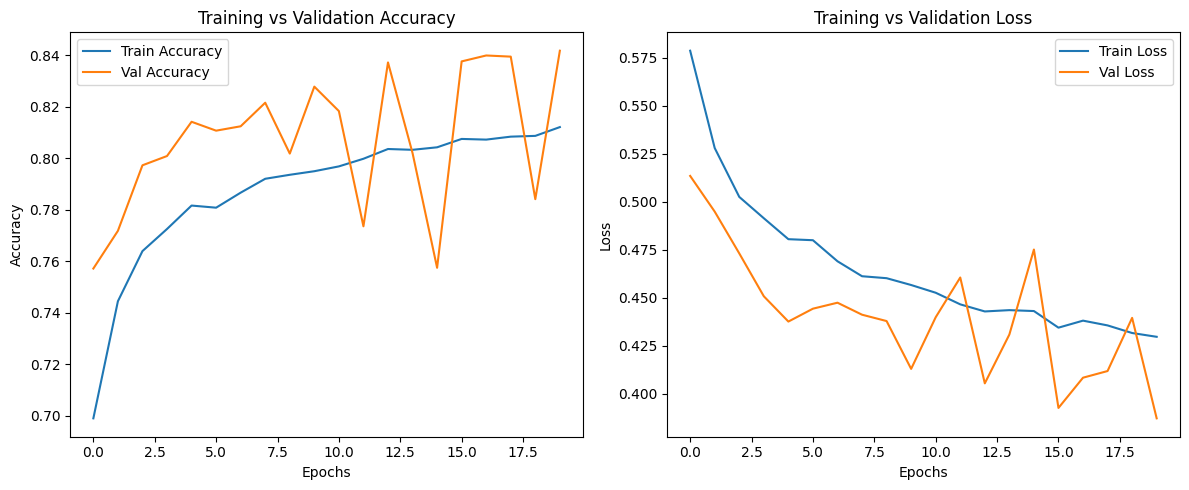

In [5]:
checkpoint = ModelCheckpoint("ssl_resnet_biomarker_best.h5", save_best_only=True)
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,
                    callbacks=[checkpoint, early_stop])
model.save("ssl_resnet_biomarker_final.h5")

test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

y_true = np.array(test_lbl)
y_pred_prob = model.predict(test_gen).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy / Loss Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
